# Weeks 3&4 
## White House Logs

In [156]:
# Load libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [157]:
# Open the files

# 2022 files leading up to 11/8/2022
june22_wh_df = pd.read_csv(
    "C:/Users/rmtol/OneDrive/Desktop/Bellevue/DCS 640/2022.06_WAVES-ACCESS-RECORDS.csv", 
    low_memory=False
)
july22_wh_df = pd.read_csv(
    "C:/Users/rmtol/OneDrive/Desktop/Bellevue/DCS 640/2022.07_WAVES-ACCESS-RECORDS.csv",
    low_memory=False
)
aug22_wh_df = pd.read_csv(
    "C:/Users/rmtol/OneDrive/Desktop/Bellevue/DCS 640/2022.08_WAVES-ACCESS-RECORDS.csv", 
    low_memory=False
)
sep22_wh_df = pd.read_csv(
    "C:/Users/rmtol/OneDrive/Desktop/Bellevue/DCS 640/2022.09_WAVES-ACCESS-RECORDS.csv", 
    low_memory=False
)
oct22_wh_df = pd.read_csv(
    "C:/Users/rmtol/OneDrive/Desktop/Bellevue/DCS 640/2022.10_WAVES-ACCESS-RECORDS.csv", 
    low_memory=False
)

# 2021
wh2021_df = pd.read_csv(
    "C:/Users/rmtol/OneDrive/Desktop/Bellevue/DCS 640/2021_WAVES-ACCESS-RECORDS White House.csv", 
    low_memory=False
)

In [158]:
# display column names for easy reference

print(june22_wh_df.columns)

Index(['Last Name', 'First Name', 'Middle Initial', 'UIN', 'BDGNBR',
       'Access Type', 'TOA', 'POA', 'TOD', 'POD', 'Appointment Made Date',
       'Appointment Start Date', 'Appointment End Date',
       'Appointment Cancel Date', 'Total People', 'Last Updated By', 'POST',
       'Last Entry Date', 'Terminal Suffix', 'Visitee Last Name',
       'Visitee First Name', 'Meeting Location', 'Meeting Room',
       'Caller Last Name', 'Caller First Name', 'CALLER_ROOM', 'RELEASEDATE'],
      dtype='object')


In [159]:
print(wh2021_df.columns)

Index(['NAMELAST', 'NAMEFIRST', 'NAMEMID', 'UIN', 'BDGNBR', 'ACCESS_TYPE',
       'TOA', 'POA', 'TOD', 'POD', 'APPT_MADE_DATE', 'APPT_START_DATE',
       'APPT_END_DATE', 'APPT_CANCEL_DATE', 'TOTAL_PEOPLE', 'LAST_UPDATEDBY',
       'POST', 'LASTENTRYDATE', 'TERMINAL_SUFFIX', 'VISITEE_NAMELAST',
       'VISITEE_NAMEFIRST', 'MEETING_LOC', 'MEETING_ROOM', 'CALLER_NAME_LAST',
       'CALLER_NAME_FIRST', 'CALLER_ROOM', 'RELEASEDATE'],
      dtype='object')


In [160]:
june22_wh_df.head()

,Last Name,First Name,Middle Initial,UIN,BDGNBR,Access Type,TOA,POA,TOD,POD,...,Last Entry Date,Terminal Suffix,Visitee Last Name,Visitee First Name,Meeting Location,Meeting Room,Caller Last Name,Caller First Name,CALLER_ROOM,RELEASEDATE
0,AANGEENBRUG,ELIZABETH,N,U55489,NaN,VA,Jun 16 2022 2:13PM,NaN,NaN,NaN,...,6/16/2022 11:17,JL,POTUS,NaN,WH,RES - State Floor,LEE,JANICE,NaN,10/4/2022
1,AARFLOT,ELIN,J,U52410,198183.0,VA,Jun 2 2022 9:34AM,NaN,NaN,B04,...,5/31/2022 10:33,LP,Raj Panjabi,Dr.,OEOB,228,PHONHARATH,LEETHA,NaN,10/4/2022
2,AARHUS,PRESTON,M,U54582,NaN,VA,NaN,NaN,NaN,NaN,...,6/10/2022 6:43,VW,Office,Visitors,WH,EW TOUR,WAVES,VISITORSOFFICE,NaN,10/4/2022
3,AARHUS,PRESTON,M,U56040,NaN,VA,Jun 18 2022 10:33AM,NaN,NaN,NaN,...,6/17/2022 19:33,EK,KNIGHT,EVA,WH,EW TOUR,KNIGHT,EVA,NaN,10/4/2022
4,AAS,SVEN,E,U57600,197687.0,VA,Jun 28 2022 10:40AM,NaN,NaN,A05,...,6/28/2022 9:19,DR,Rodriguez,Drew,OEOB,260,RODRIGUEZ,DREW,NaN,10/4/2022


In [161]:
# combine datasets to one year file
# for 2022

fall2022_df = pd.concat([june22_wh_df, july22_wh_df, aug22_wh_df, sep22_wh_df, oct22_wh_df])

In [162]:
# Convert appointment start date to datetime

fall2022_df['Appointment Start Date'] = pd.to_datetime(
    fall2022_df['Appointment Start Date'], errors='coerce'
)

In [163]:
# Create a new variable for each week for easier viewing

fall2022_df['WEEK'] = (
    fall2022_df['Appointment Start Date']
    .dt.to_period('W').apply(lambda r: r.start_time)
)

In [164]:
# Group by week and count visitors per week

weekly2022_visits = fall2022_df.groupby('WEEK').size()

# Display the weekly visitor counts

print(weekly2022_visits)

WEEK
2022-05-30     2728
2022-06-06     3433
2022-06-13     5633
2022-06-20     4349
2022-06-27     4345
2022-07-04    11267
2022-07-11     9157
2022-07-18     7977
2022-07-25     8291
2022-08-01     7482
2022-08-08     8006
2022-08-15     7247
2022-08-22     6687
2022-08-29     5703
2022-09-05     5815
2022-09-12    11644
2022-09-19    10244
2022-09-26     7260
2022-10-03     7061
2022-10-10     8207
2022-10-17     8259
2022-10-24     8442
2022-10-31     5560
dtype: int64


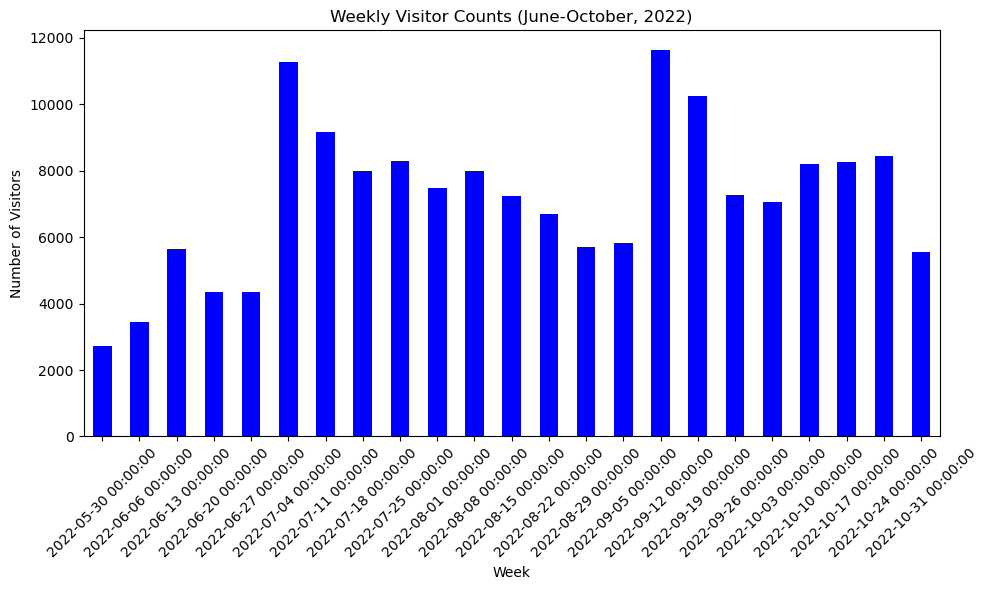

In [165]:
# Plot visitor trends weeks leading up to 11/8/2022 by week

plt.figure(figsize=(10, 6))
weekly2022_visits.plot(kind='bar', color='blue')
plt.title("Weekly Visitor Counts (June-October, 2022)")
plt.xlabel("Week")
plt.ylabel("Number of Visitors")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [166]:
# Convert appointment start date to datetime for 2021 file

wh2021_df['APPT_START_DATE'] = pd.to_datetime(
    wh2021_df['APPT_START_DATE'], errors='coerce'
)

In [167]:
# Create a new variable for each week for easier viewing

wh2021_df['WEEK'] = (
    wh2021_df['APPT_START_DATE']
    .dt.to_period('W').apply(lambda r: r.start_time)
)

In [168]:
# Filter the dataset for weeks between June and October to match 2022

start_date = '2021-05-31'
end_date = '2021-10-30'

# Filter rows where the new "WEEK" column falls within the dates

wh2021_filtered_df = wh2021_df[(wh2021_df['WEEK']>= start_date) & (wh2021_df['WEEK']<= end_date)]

In [169]:
# Group by week and count the number of visitors per week

weekly2021_visits = wh2021_filtered_df.groupby('WEEK').size()

# Display the weekly visitor counts

print(weekly2021_visits)

WEEK
2021-05-31     351
2021-06-07     356
2021-06-14     668
2021-06-21     643
2021-06-28    2047
2021-07-05     563
2021-07-12    1045
2021-07-19    1250
2021-07-26     858
2021-08-02     612
2021-08-09     470
2021-08-16     386
2021-08-23     571
2021-08-30     272
2021-09-06     409
2021-09-13     429
2021-09-20    1131
2021-09-27     564
2021-10-04     784
2021-10-11     538
2021-10-18     823
2021-10-25     598
dtype: int64


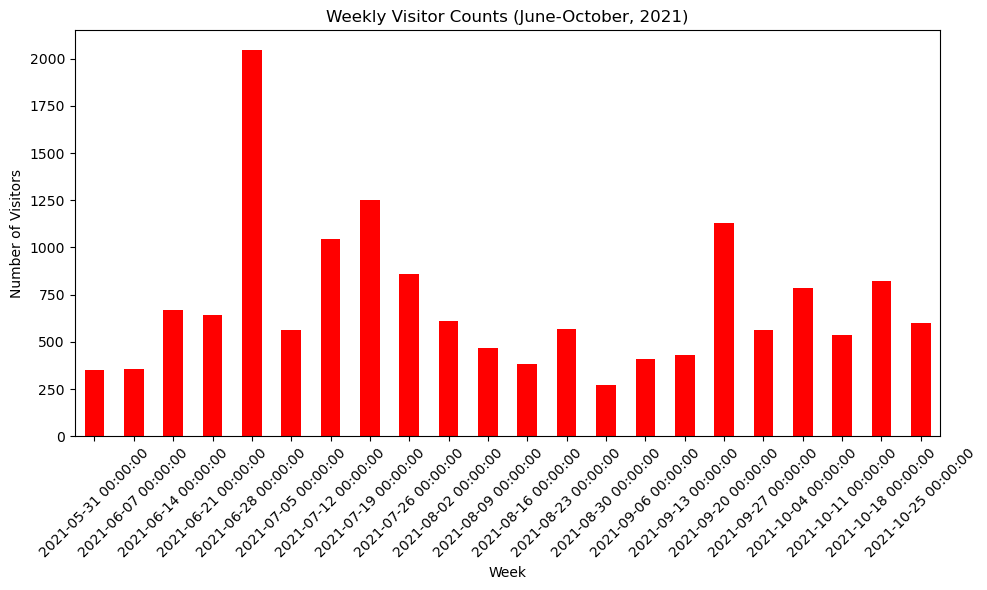

In [170]:
# Plot visitor trends weeks leading up to Nov 2021 by week

plt.figure(figsize=(10, 6))
weekly2021_visits.plot(kind='bar', color='red')
plt.title("Weekly Visitor Counts (June-October, 2021)")
plt.xlabel("Week")
plt.ylabel("Number of Visitors")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

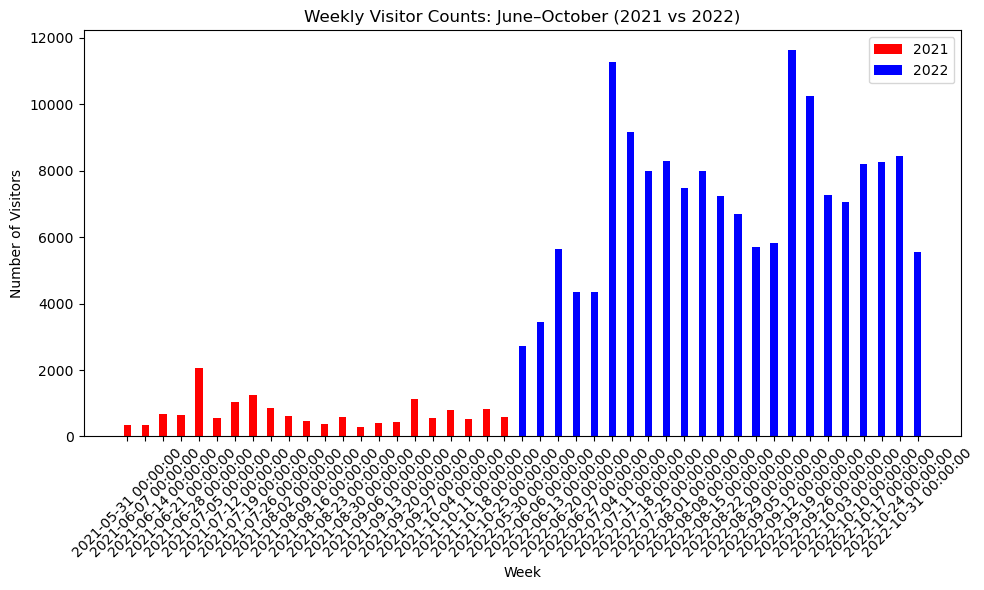

In [171]:
# compare the 2 years

# Align weeks for both datasets
weeks = sorted(set(weekly2021_visits.index).union(set(weekly2022_visits.index)))
visits_2021 = [weekly2021_visits.get(week, 0) for week in weeks]
visits_2022 = [weekly2022_visits.get(week, 0) for week in weeks]

# Create the stacked bar chart
x = np.arange(len(weeks))
width = 0.4

plt.figure(figsize=(10, 6))
plt.bar(x, visits_2021, width, label='2021', color='red')
plt.bar(x, visits_2022, width, bottom=visits_2021, label='2022', color='blue')
plt.title("Weekly Visitor Counts: June–October (2021 vs 2022)")
plt.xlabel("Week")
plt.ylabel("Number of Visitors")
plt.xticks(x, weeks, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


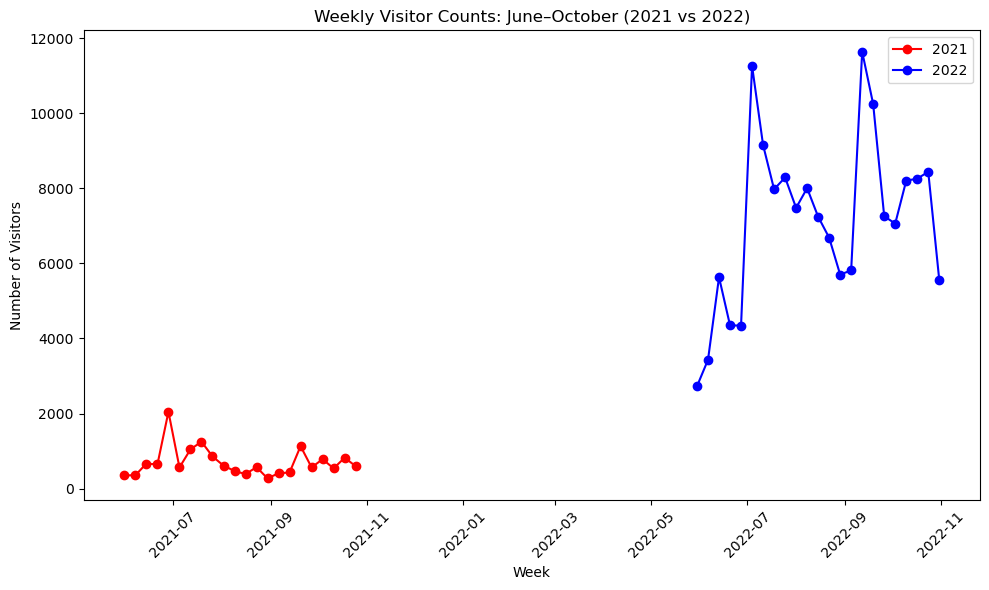

In [172]:
# Group data by week and count visitors for 2021 and 2022
weekly2021_visits = wh2021_filtered_df.groupby('WEEK').size()
weekly2022_visits = fall2022_df.groupby('WEEK').size()

# Plot the line chart
plt.figure(figsize=(10, 6))
plt.plot(weekly2021_visits.index,weekly2021_visits.values,label='2021',color='red',marker='o')
plt.plot(weekly2022_visits.index,weekly2022_visits.values,label='2022',color='blue',marker='o')
plt.title("Weekly Visitor Counts: June–October (2021 vs 2022)")
plt.xlabel("Week")
plt.ylabel("Number of Visitors")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

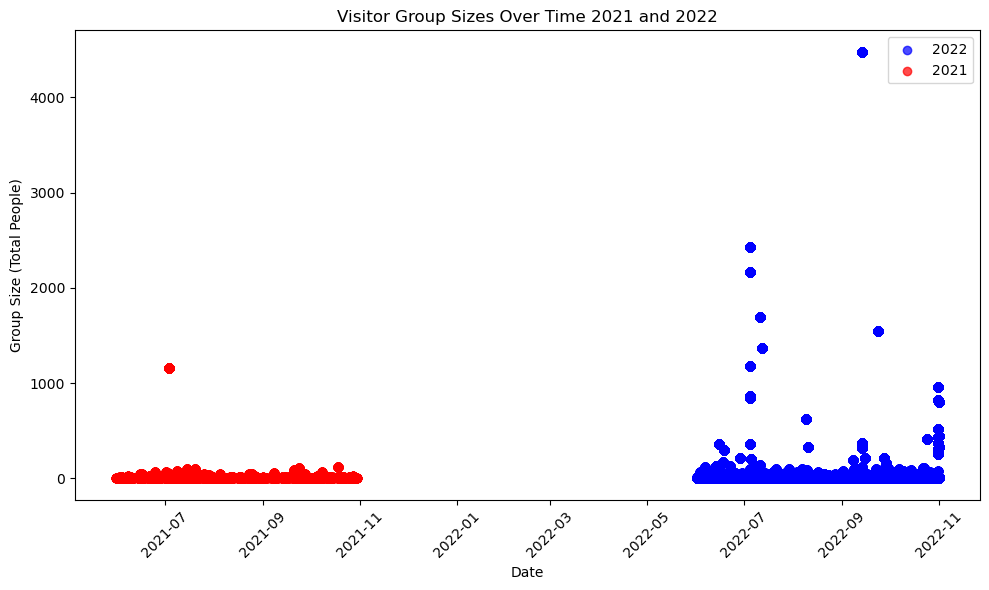

In [173]:
# create scatter plot of Visitor Count by Date
plt.figure(figsize=(10, 6))
plt.scatter(
    fall2022_df['Appointment Start Date'], 
    fall2022_df['Total People'], 
    alpha=0.7, 
    color='blue', 
    label='2022'
)
plt.scatter(
    wh2021_filtered_df['APPT_START_DATE'], 
    wh2021_filtered_df['TOTAL_PEOPLE'], 
    alpha=0.7, 
    color='red', 
    label='2021'
)
plt.title("Visitor Group Sizes Over Time 2021 and 2022")
plt.xlabel("Date")
plt.ylabel("Group Size (Total People)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [174]:
# Group by week and meeting location and get number of meetings each week by location

meeting_counts = fall2022_df.groupby(['WEEK', 'Meeting Location']).size().unstack(fill_value=0)

In [175]:
# calculate cumulative meeting counts by location

cumulative_counts = meeting_counts.cumsum()

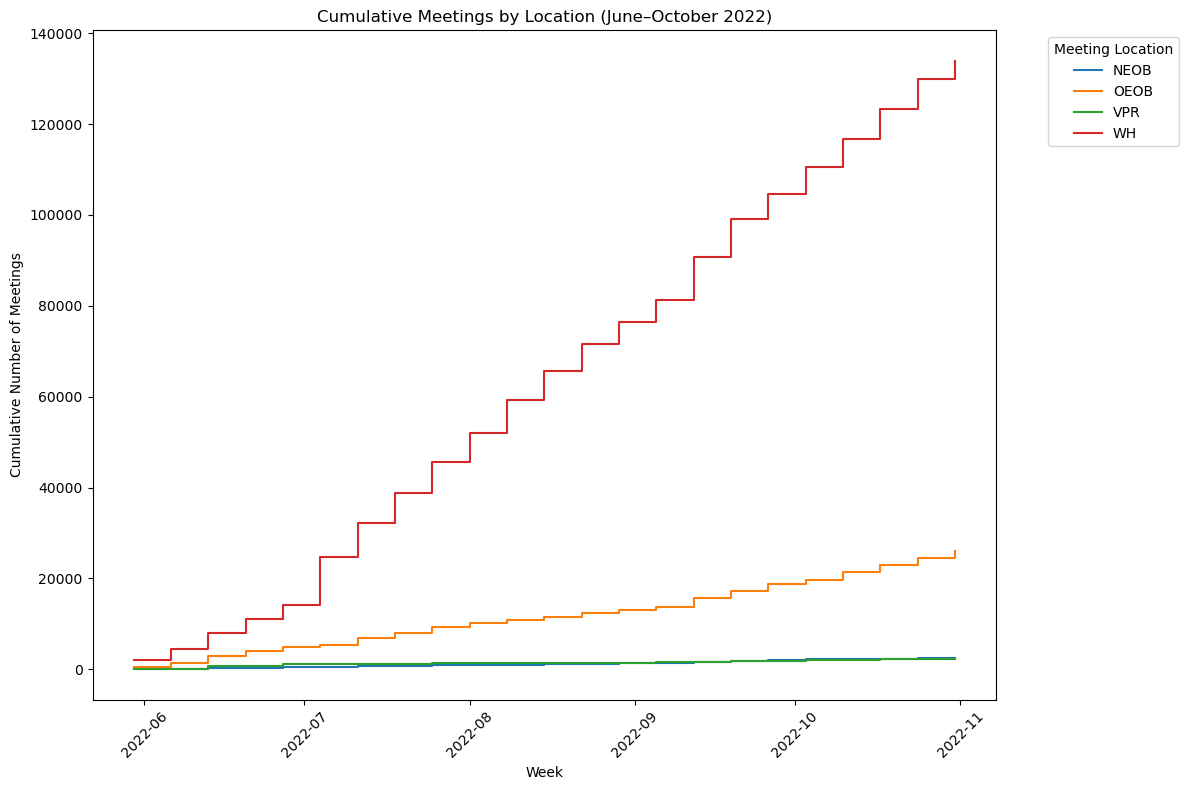

In [176]:
# Plot the step chart

plt.figure(figsize=(12, 8))
for location in cumulative_counts.columns:
    plt.step(cumulative_counts.index, cumulative_counts[location], where='post', label=location)

plt.title("Cumulative Meetings by Location (June–October 2022)")
plt.xlabel("Week")
plt.ylabel("Cumulative Number of Meetings")
plt.legend(title="Meeting Location", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [177]:
# Filter the data for visitee as POTUS and VPOTUS

visitee_filtered_df = fall2022_df[
    (fall2022_df['Visitee Last Name'] == 'POTUS') |
    (fall2022_df['Visitee Last Name'] == 'VPOTUS')
]

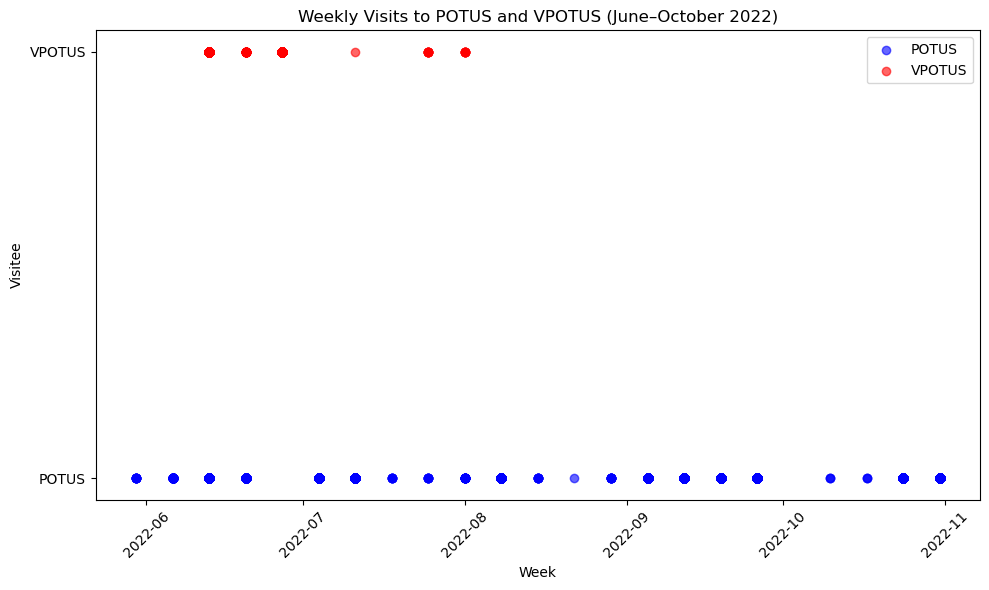

In [178]:
# Scatterplot of POTUS and VPOTUS for each week

plt.figure(figsize=(10, 6))
plt.scatter(
    visitee_filtered_df[visitee_filtered_df['Visitee Last Name'] == 'POTUS']['WEEK'],
    [1] * len(visitee_filtered_df[visitee_filtered_df['Visitee Last Name'] == 'POTUS']),
    alpha=0.6, color='blue', label='POTUS'
)
plt.scatter(
    visitee_filtered_df[visitee_filtered_df['Visitee Last Name'] == 'VPOTUS']['WEEK'],
    [2] * len(visitee_filtered_df[visitee_filtered_df['Visitee Last Name'] == 'VPOTUS']),
    alpha=0.6, color='red', label='VPOTUS'
)
plt.title("Weekly Visits to POTUS and VPOTUS (June–October 2022)")
plt.xlabel("Week")
plt.ylabel("Visitee")
plt.yticks([1, 2], ['POTUS', 'VPOTUS'])
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [179]:
# Create a new column for caller categories (TOUR, VISITORSOFFICE, Other)

fall2022_df['CALLER_CATEGORY'] = fall2022_df['Caller First Name'].apply(
    lambda x: 'TOUR' if x == 'TOUR' else 'VISITORSOFFICE' if x == 'VISITORSOFFICE' else 'Other'
)

In [180]:
# Group by WEEK and new CALLER_CATEGORY to calculate counts

weekly_counts = (
    fall2022_df
    .groupby(['WEEK', 'CALLER_CATEGORY'])
    .size()
    .unstack(fill_value=0)
)

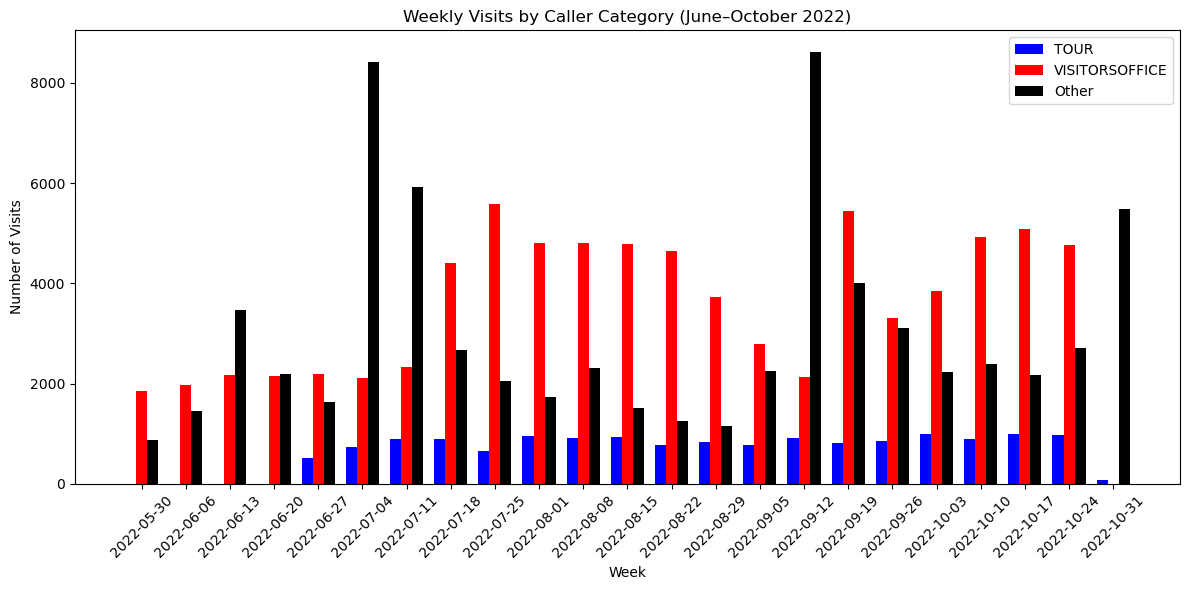

In [181]:
# Plot a grouped column chart

x = np.arange(len(weekly_counts))  
width = 0.25  

plt.figure(figsize=(12, 6))
plt.bar(x - width, weekly_counts['TOUR'], width, label='TOUR', color='blue')
plt.bar(x, weekly_counts['VISITORSOFFICE'], width, label='VISITORSOFFICE', color='red')
plt.bar(x + width, weekly_counts['Other'], width, label='Other', color='black')

plt.title("Weekly Visits by Caller Category (June–October 2022)")
plt.xlabel("Week")
plt.ylabel("Number of Visits")
plt.xticks(x, weekly_counts.index.strftime('%Y-%m-%d'), rotation=45) 
plt.legend()
plt.tight_layout()
plt.show()